# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Baseline Models

Today we work on the simplest models to act as a starting point that we will beat.

In [1]:
# imports

import os
import math
import json
import random
from dotenv import load_dotenv
from huggingface_hub import login
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter

In [2]:
# More imports for our traditional machine learning

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

## NLP imports

In the next cell, we have more imports for our NLP related machine learning.  
If the gensim import gives you an error like "Cannot import name 'triu' from 'scipy.linalg' then please run in another cell:  
`!pip install "scipy<1.13"`  
As described on StackOverflow [here](https://stackoverflow.com/questions/78279136/importerror-cannot-import-name-triu-from-scipy-linalg-when-importing-gens).  
Many thanks to students Arnaldo G and Ard V for sorting this.

In [3]:
# NLP related imports

from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

In [4]:
# Finally, more imports for more advanced machine learning

from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor

In [5]:
# Constants - used for printing to stdout in color

GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red":RED, "orange": YELLOW, "green": GREEN}

In [6]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [7]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [8]:
# One more import after logging in

from items import Item

In [9]:
%matplotlib inline

# Loading the pkl files

Let's avoid curating all our data again! Load in the pickle files

If you didn't already create these in Day 2, you can also download them from my google drive (you'll also find the slides here):  
https://drive.google.com/drive/folders/1JwNorpRHdnf_pU0GE5yYtfKlyrKC3CoV?usp=sharing

But note that the files are quite large - you might need to get a coffee!

In [10]:
with open('train.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)

In [11]:
# Remind ourselves the training prompt

print(train[0].prompt)

How much does this cost to the nearest dollar?

Delphi FG0166 Fuel Pump Module
Delphi brings 80 years of OE Heritage into each Delphi pump, ensuring quality and fitment for each Delphi part. Part is validated, tested and matched to the right vehicle application Delphi brings 80 years of OE Heritage into each Delphi assembly, ensuring quality and fitment for each Delphi part Always be sure to check and clean fuel tank to avoid unnecessary returns Rigorous OE-testing ensures the pump can withstand extreme temperatures Brand Delphi, Fit Type Vehicle Specific Fit, Dimensions LxWxH 19.7 x 7.7 x 5.1 inches, Weight 2.2 Pounds, Auto Part Position Unknown, Operation Mode Mechanical, Manufacturer Delphi, Model FUEL PUMP, Dimensions 19.7

Price is $227.00


In [12]:
# Remind a test prompt

print(train[0].price)

226.95


## Unveiling a mighty script that we will use a lot!

A rather pleasing Test Harness that will evaluate any model against 250 items from the Test set

And show us the results in a visually satisfying way.

You write a function of this form:

```
def my_prediction_function(item):
    # my code here
    return my_estimate
```

And then you call:

`Tester.test(my_prediction_function)`

To evaluate your model.

In [13]:
class Tester:

    def __init__(self, predictor, title=None, data=test, size=250):
        self.predictor = predictor
        self.data = data
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size
        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if error<40 or error/truth < 0.2:
            return "green"
        elif error<80 or error/truth < 0.4:
            return "orange"
        else:
            return "red"
    
    def run_datapoint(self, i):
        datapoint = self.data[i]
        guess = self.predictor(datapoint)
        truth = datapoint.price
        error = abs(guess - truth)
        log_error = math.log(truth+1) - math.log(guess+1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        title = datapoint.title if len(datapoint.title) <= 40 else datapoint.title[:40]+"..."
        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)
        print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{RESET}")

    def chart(self, title):
        max_error = max(self.errors)
        plt.figure(figsize=(12, 8))
        max_val = max(max(self.truths), max(self.guesses))
        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Ground Truth')
        plt.ylabel('Model Estimate')
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color=="green")
        title = f"{self.title} Error=${average_error:,.2f} RMSLE={rmsle:,.2f} Hits={hits/self.size*100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)
        self.report()

    @classmethod
    def test(cls, function):
        cls(function).run()

# Now for something basic

What's the very simplest model you could imagine?

Let's start with a random number generator!

In [14]:
def random_pricer(item):
    return random.randrange(1,1000)

1: Guess: $655.00 Truth: $374.41 Error: $280.59 SLE: 0.31 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $115.00 Truth: $225.00 Error: $110.00 SLE: 0.44 Item: Microsoft Surface 3 7G6-00001 10.8 Inch ...
3: Guess: $26.00 Truth: $61.73 Error: $35.73 SLE: 0.71 Item: Dorman 741-714 Front Passenger Side Powe...
4: Guess: $760.00 Truth: $599.99 Error: $160.01 SLE: 0.06 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $282.00 Truth: $16.97 Error: $265.03 SLE: 7.60 Item: The Best Card Company - 20 Bulk Animal N...
6: Guess: $251.00 Truth: $31.99 Error: $219.01 SLE: 4.13 Item: ITSHINY Waterproof Laptop Travel Backpac...
7: Guess: $229.00 Truth: $101.55 Error: $127.45 SLE: 0.65 Item: Uniweld MTF-9 Cap'n Hook 9 Flame Tip sil...
8: Guess: $143.00 Truth: $289.00 Error: $146.00 SLE: 0.49 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $755.00 Truth: $635.86 Error: $119.14 SLE: 0.03 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $105.00 Truth: $66.00 

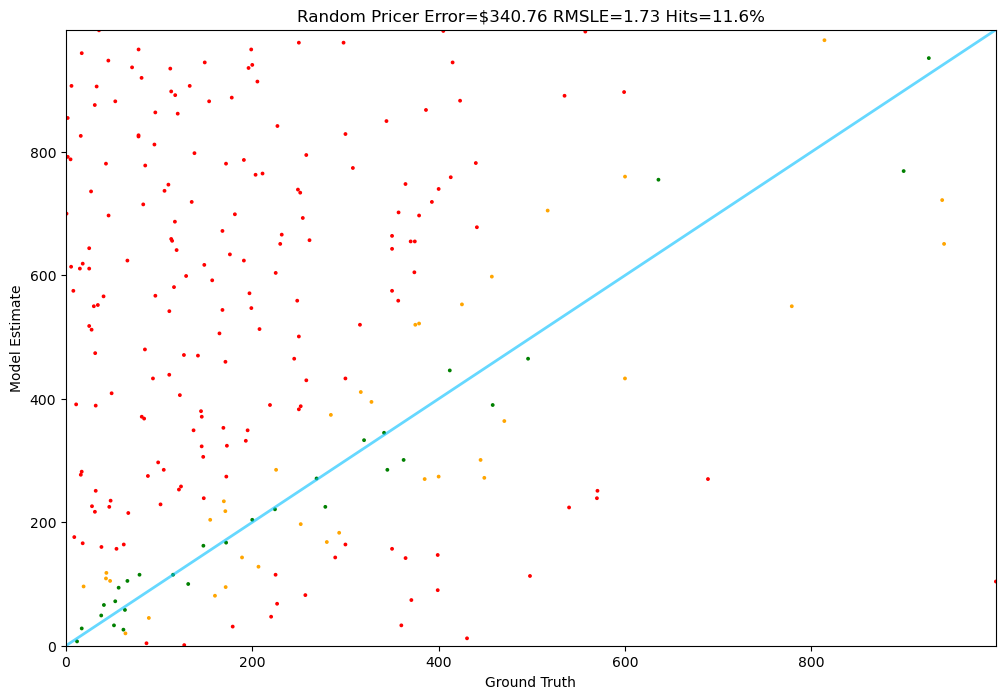

In [15]:
# Set the random seed

random.seed(42)

# Run our TestRunner
Tester.test(random_pricer)

In [16]:
# That was fun!
# We can do better - here's another rather trivial model

training_prices = [item.price for item in train]
training_average = sum(training_prices) / len(training_prices)

def constant_pricer(item):
    return training_average

1: Guess: $220.46 Truth: $374.41 Error: $153.95 SLE: 0.28 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $220.46 Truth: $225.00 Error: $4.54 SLE: 0.00 Item: Microsoft Surface 3 7G6-00001 10.8 Inch ...
3: Guess: $220.46 Truth: $61.73 Error: $158.73 SLE: 1.59 Item: Dorman 741-714 Front Passenger Side Powe...
4: Guess: $220.46 Truth: $599.99 Error: $379.53 SLE: 1.00 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $220.46 Truth: $16.97 Error: $203.49 SLE: 6.31 Item: The Best Card Company - 20 Bulk Animal N...
6: Guess: $220.46 Truth: $31.99 Error: $188.47 SLE: 3.63 Item: ITSHINY Waterproof Laptop Travel Backpac...
7: Guess: $220.46 Truth: $101.55 Error: $118.91 SLE: 0.59 Item: Uniweld MTF-9 Cap'n Hook 9 Flame Tip sil...
8: Guess: $220.46 Truth: $289.00 Error: $68.54 SLE: 0.07 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $220.46 Truth: $635.86 Error: $415.40 SLE: 1.12 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $220.46 Truth: $66.00 E

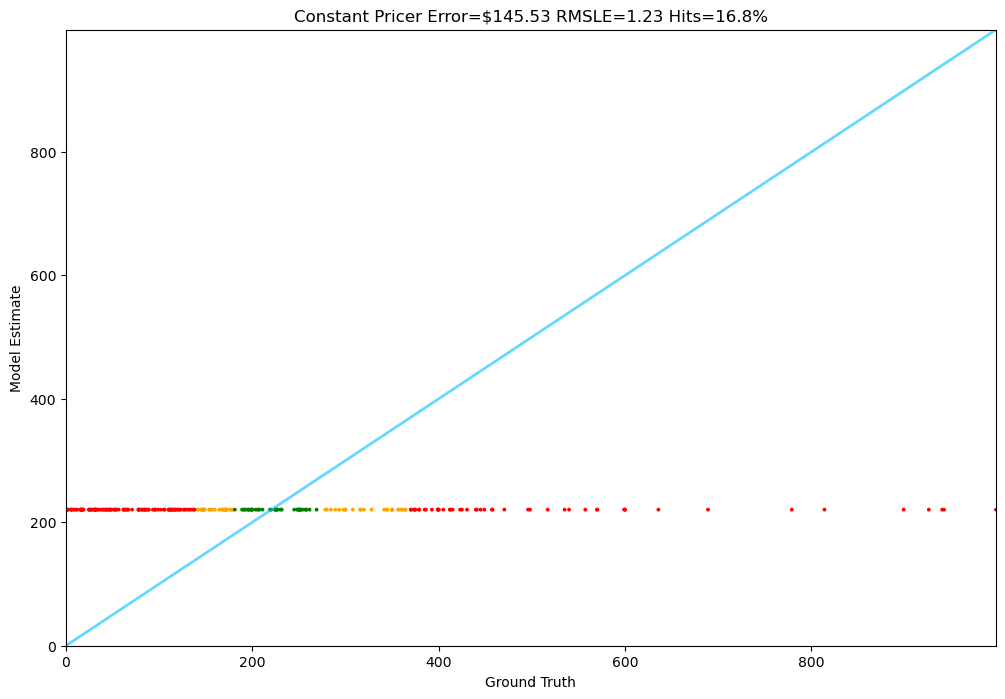

In [17]:
# Run our constant predictor
Tester.test(constant_pricer)


In [18]:
train[0].details

'{"Brand": "Delphi", "Fit Type": "Vehicle Specific Fit", "Item Dimensions LxWxH": "19.7 x 7.7 x 5.1 inches", "Item Weight": "2.2 Pounds", "Auto Part Position": "Unknown", "Operation Mode": "Mechanical", "Manufacturer": "Delphi", "Model": "FUEL PUMP", "Product Dimensions": "19.7 x 7.7 x 5.1 inches", "Country of Origin": "USA", "Item model number": "FG0166", "Is Discontinued By Manufacturer": "No", "Exterior": "Painted", "Manufacturer Part Number": "FG0166", "OEM Part Number": "25326856, 89060639, A30416, E4061R, MU242", "Best Sellers Rank": {"Automotive": 913571, "Automotive Replacement Electric Fuel Pumps": 6568}, "Domestic Shipping": "Item can be shipped within U.S.", "International Shipping": "This item is not eligible for international shipping.  Learn More", "Date First Available": "August 9, 2006"}'

In [19]:
# Create a new "features" field on items, and populate it with json parsed from the details dict

for item in train:
    item.features = json.loads(item.details)
for item in test:
    item.features = json.loads(item.details)

# Look at one

In [20]:
train[0].features.keys()

dict_keys(['Brand', 'Fit Type', 'Item Dimensions LxWxH', 'Item Weight', 'Auto Part Position', 'Operation Mode', 'Manufacturer', 'Model', 'Product Dimensions', 'Country of Origin', 'Item model number', 'Is Discontinued By Manufacturer', 'Exterior', 'Manufacturer Part Number', 'OEM Part Number', 'Best Sellers Rank', 'Domestic Shipping', 'International Shipping', 'Date First Available'])

In [21]:
# Look at 20 most common features in training set

feature_count = Counter()
for item in train:
    for f in item.features.keys():
        feature_count[f]+=1

feature_count.most_common(40)

[('Date First Available', 359300),
 ('Item Weight', 350777),
 ('Manufacturer', 349073),
 ('Brand', 340726),
 ('Best Sellers Rank', 331045),
 ('Item model number', 276845),
 ('Product Dimensions', 262600),
 ('Color', 182773),
 ('Is Discontinued By Manufacturer', 169374),
 ('Manufacturer Part Number', 151577),
 ('Material', 138011),
 ('Country of Origin', 121232),
 ('Style', 77226),
 ('Part Number', 73341),
 ('Package Dimensions', 72941),
 ('Special Feature', 72710),
 ('Batteries Required?', 72376),
 ('Item Dimensions LxWxH', 71962),
 ('Model', 67489),
 ('Included Components', 66634),
 ('Size', 58535),
 ('OEM Part Number', 58529),
 ('Item Package Quantity', 57569),
 ('Batteries Included?', 55943),
 ('Special Features', 54212),
 ('Exterior', 52549),
 ('Vehicle Service Type', 51401),
 ('Power Source', 49611),
 ('Finish Type', 45737),
 ('Voltage', 45474),
 ('Mounting Type', 37549),
 ('Model Name', 36649),
 ('Shape', 34780),
 ('Number of Items', 31974),
 ('Finish', 31496),
 ('Connectivity Te

In [22]:
# Now some janky code to pluck out the Item Weight
# Don't worry too much about this: spoiler alert, it's not going to be much use in training!

def get_weight(item):
    weight_str = item.features.get('Item Weight')
    if weight_str:
        parts = weight_str.split(' ')
        amount = float(parts[0])
        unit = parts[1].lower()
        if unit=="pounds":
            return amount
        elif unit=="ounces":
            return amount / 16
        elif unit=="grams":
            return amount / 453.592
        elif unit=="milligrams":
            return amount / 453592
        elif unit=="kilograms":
            return amount / 0.453592
        elif unit=="hundredths" and parts[2].lower()=="pounds":
            return amount / 100
        else:
            print(weight_str)
    return None

In [23]:
weights = [get_weight(t) for t in train]
weights = [w for w in weights if w]

In [24]:
average_weight = sum(weights)/len(weights)
average_weight

13.689079552696723

In [25]:
def get_weight_with_default(item):
    weight = get_weight(item)
    return weight or average_weight

In [26]:
def get_rank(item):
    rank_dict = item.features.get("Best Sellers Rank")
    if rank_dict:
        ranks = rank_dict.values()
        return sum(ranks)/len(ranks)
    return None

In [27]:
ranks = [get_rank(t) for t in train]
ranks = [r for r in ranks if r]
average_rank = sum(ranks)/len(ranks)
average_rank

389669.6467578932

In [28]:
def get_rank_with_default(item):
    rank = get_rank(item)
    return rank or average_rank

In [29]:
def get_text_length(item):
    return len(item.test_prompt())

In [30]:
# investigate the brands

brands = Counter()
for t in train:
    brand = t.features.get("Brand")
    if brand:
        brands[brand]+=1

# Look at most common 40 brands

brands.most_common(40)

[('HP', 5405),
 ('Power Stop', 3641),
 ('Dell', 3172),
 ('Detroit Axle', 2831),
 ('Lenovo', 2384),
 ('Dorman', 2333),
 ('BUYAUTOPARTS!', 1742),
 ('SAMSUNG', 1696),
 ('ACDelco', 1650),
 ('Evan Fischer', 1513),
 ('ASUS', 1349),
 ('Sony', 1217),
 ('Canon', 1213),
 ('Callahan BRAKE PARTS', 1175),
 ('Kohler', 1127),
 ('CURT', 1104),
 ('R1 Concepts', 1061),
 ('Rareelectrical', 1009),
 ('Coverking', 982),
 ('Garage-Pro', 944),
 ('Spectra Premium', 889),
 ('Auto Dynasty', 874),
 ('Moen', 872),
 ('Kingston Brass', 847),
 ('WeatherTech', 841),
 ('Cardone', 837),
 ('APS', 812),
 ('K&N', 797),
 ('DELTA FAUCET', 797),
 ('Apple', 759),
 ('Walker', 749),
 ('GM', 737),
 ('EBC Brakes', 736),
 ('Generic', 727),
 ('A-Premium', 692),
 ('TYC', 688),
 ('AKKON', 672),
 ('DB Electrical', 644),
 ('SPEC-D TUNING', 642),
 ('ECCPP', 641)]

In [31]:
TOP_ELECTRONICS_BRANDS = ["hp", "dell", "lenovo", "samsung", "asus", "sony", "canon", "apple", "intel"]
def is_top_electronics_brand(item):
    brand = item.features.get("Brand")
    return brand and brand.lower() in TOP_ELECTRONICS_BRANDS

In [32]:
def get_features(item):
    return {
        "weight": get_weight_with_default(item),
        "rank": get_rank_with_default(item),
        "text_length": get_text_length(item),
        "is_top_electronics_brand": 1 if is_top_electronics_brand(item) else 0
    }

In [33]:
# Look at features in a training item
get_features(train[0])

{'weight': 2.2,
 'rank': 460069.5,
 'text_length': 748,
 'is_top_electronics_brand': 0}

In [34]:
# A utility function to convert our features into a pandas dataframe

def list_to_dataframe(items):
    features = [get_features(item) for item in items]
    df = pd.DataFrame(features)
    df['price'] = [item.price for item in items]
    return df

train_df = list_to_dataframe(train)
test_df = list_to_dataframe(test[:250])

In [42]:
# Traditional Linear Regression!

np.random.seed(42)

# Separate features and target
feature_columns = ['weight', 'rank', 'text_length', 'is_top_electronics_brand']

X_train = train_df[feature_columns]
y_train = train_df['price']
X_test = test_df[feature_columns]
y_test = test_df['price']

# Train a Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

for feature, coef in zip(feature_columns, model.coef_):
    print(f"{feature}: {coef}")
print(f"Intercept: {model.intercept_}")

# Predict the test set and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

weight: 3.1828260260459076
rank: 9.887360039860887
text_length: 1.8057715119334654
is_top_electronics_brand: 199.68582445955192
Intercept: 213.91824917778618
Mean Squared Error: 31296550101324.19
R-squared Score: -861144449.4714147


In [43]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Set random seed
np.random.seed(42)

try:
    # Get all feature columns (exclude 'price')
    feature_columns = [col for col in train_df.columns if col != 'price']
    print(f"Using {len(feature_columns)} features")
    print(f"Features: {feature_columns}")

    X_train = train_df[feature_columns]
    y_train = train_df['price']
    X_test = test_df_enhanced[feature_columns]
    y_test = test_df_enhanced['price']

    print(f"Training data shape: {X_train.shape}")
    print(f"Test data shape: {X_test.shape}")

    # Create enhanced model pipeline
    model_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
        ('ridge', Ridge(alpha=10.0))
    ])

    # Train the model
    print("Training model...")
    model_pipeline.fit(X_train, y_train)
    print("Model training completed!")

    # Predict and evaluate
    y_pred = model_pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\nEnhanced Model Results:")
    print(f"Mean Squared Error: {mse:,.2f}")
    print(f"R-squared Score: {r2:.4f}")
    print(f"Improvement in R²: {r2 - 0.0391:.4f}")

    # Verify model_pipeline exists
    print(f"\nmodel_pipeline created successfully: {type(model_pipeline)}")
    
except Exception as e:
    print(f"Error in Cell 39: {e}")
    print("Please check the previous cells (36, 38) ran successfully")

Using 18 features
Features: ['weight', 'rank', 'text_length', 'is_top_electronics_brand', 'category_Automotive', 'category_Electronics', 'category_Office_Products', 'category_Tools_and_Home_Improvement', 'category_Cell_Phones_and_Accessories', 'category_Toys_and_Games', 'category_Appliances', 'category_Musical_Instruments', 'title_length', 'title_words', 'expensive_keywords', 'feature_count', 'has_dimensions', 'has_warranty']
Training data shape: (400000, 18)
Test data shape: (250, 18)
Training model...
Model training completed!

Enhanced Model Results:
Mean Squared Error: 25,700.33
R-squared Score: 0.2928
Improvement in R²: 0.2537

model_pipeline created successfully: <class 'sklearn.pipeline.Pipeline'>


In [40]:
def get_enhanced_features(item):
    features = {}
    
    # Original features (improved)
    features["weight"] = get_weight_with_default(item)
    features["rank"] = math.log(get_rank_with_default(item) + 1)  # Log transform
    features["text_length"] = get_text_length(item)
    features["is_top_electronics_brand"] = 1 if is_top_electronics_brand(item) else 0
    
    # Category features (one-hot encoded)
    for category in ['Automotive', 'Electronics', 'Office_Products', 
                     'Tools_and_Home_Improvement', 'Cell_Phones_and_Accessories',
                     'Toys_and_Games', 'Appliances', 'Musical_Instruments']:
        features[f"category_{category}"] = 1 if item.category == category else 0
    
    # Title analysis
    title = item.title.lower() if hasattr(item, 'title') else ""
    features["title_length"] = len(title)
    features["title_words"] = len(title.split())
    
    # High-value keywords
    expensive_keywords = ['professional', 'premium', 'deluxe', 'pro', 'advanced', 'studio']
    features["expensive_keywords"] = sum(1 for kw in expensive_keywords if kw in title)
    
    # Product details richness
    features["feature_count"] = len(item.features.keys())
    features["has_dimensions"] = 1 if any('dimension' in k.lower() for k in item.features.keys()) else 0
    features["has_warranty"] = 1 if any('warranty' in k.lower() for k in item.features.keys()) else 0
    
    return features

In [41]:
from sklearn.preprocessing import RobustScaler

def list_to_enhanced_dataframe(items):
    features = [get_enhanced_features(item) for item in items]
    df = pd.DataFrame(features)
    df['price'] = [item.price for item in items]
    
    # Identify numerical features that need scaling
    numerical_features = ['weight', 'rank', 'text_length', 'title_length', 
                         'title_words', 'feature_count']
    
    # Scale numerical features
    scaler = RobustScaler()  # More robust to outliers than StandardScaler
    df[numerical_features] = scaler.fit_transform(df[numerical_features])
    
    return df, scaler

# Create enhanced dataframes
train_df, scaler = list_to_enhanced_dataframe(train)
test_df_enhanced = pd.DataFrame([get_enhanced_features(item) for item in test[:250]])
test_df_enhanced['price'] = [item.price for item in test[:250]]

# Apply same scaling to test set
numerical_features = ['weight', 'rank', 'text_length', 'title_length', 
                     'title_words', 'feature_count']
test_df_enhanced[numerical_features] = scaler.transform(test_df_enhanced[numerical_features])

print(f"Training features shape: {train_df.shape}")
print(f"Feature columns: {list(train_df.columns)}")

Training features shape: (400000, 19)
Feature columns: ['weight', 'rank', 'text_length', 'is_top_electronics_brand', 'category_Automotive', 'category_Electronics', 'category_Office_Products', 'category_Tools_and_Home_Improvement', 'category_Cell_Phones_and_Accessories', 'category_Toys_and_Games', 'category_Appliances', 'category_Musical_Instruments', 'title_length', 'title_words', 'expensive_keywords', 'feature_count', 'has_dimensions', 'has_warranty', 'price']


In [44]:
def enhanced_linear_regression_pricer(item):
    features = get_enhanced_features(item)
    features_df = pd.DataFrame([features])
    
    # Apply same scaling to numerical features
    numerical_features = ['weight', 'rank', 'text_length', 'title_length', 
                         'title_words', 'feature_count']
    features_df[numerical_features] = scaler.transform(features_df[numerical_features])
    
    # Get feature columns in same order as training
    feature_columns = [col for col in train_df.columns if col != 'price']
    features_df = features_df[feature_columns]
    
    # Predict
    prediction = model_pipeline.predict(features_df)[0]
    return max(prediction, 1.0)  # Ensure positive price

1: Guess: $256.20 Truth: $374.41 Error: $118.21 SLE: 0.14 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $387.44 Truth: $225.00 Error: $162.44 SLE: 0.29 Item: Microsoft Surface 3 7G6-00001 10.8 Inch ...
3: Guess: $242.79 Truth: $61.73 Error: $181.06 SLE: 1.84 Item: Dorman 741-714 Front Passenger Side Powe...
4: Guess: $428.43 Truth: $599.99 Error: $171.56 SLE: 0.11 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $75.75 Truth: $16.97 Error: $58.78 SLE: 2.11 Item: The Best Card Company - 20 Bulk Animal N...
6: Guess: $198.08 Truth: $31.99 Error: $166.09 SLE: 3.23 Item: ITSHINY Waterproof Laptop Travel Backpac...
7: Guess: $159.73 Truth: $101.55 Error: $58.18 SLE: 0.20 Item: Uniweld MTF-9 Cap'n Hook 9 Flame Tip sil...
8: Guess: $155.75 Truth: $289.00 Error: $133.25 SLE: 0.38 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $456.36 Truth: $635.86 Error: $179.50 SLE: 0.11 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $117.72 Truth: $66.00 E

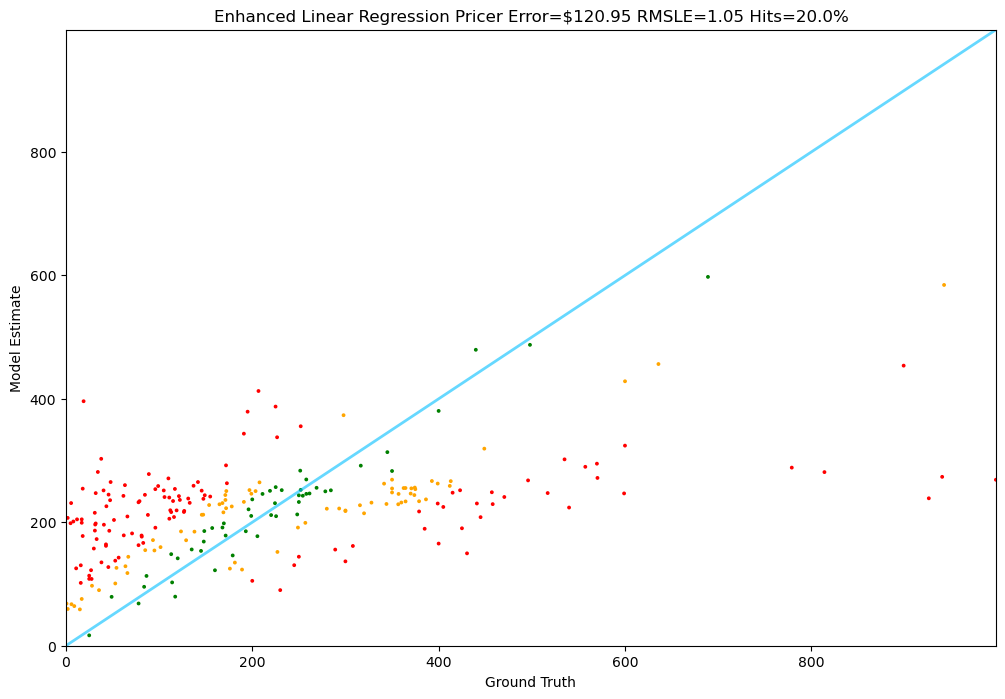

In [45]:
Tester.test(enhanced_linear_regression_pricer)

In [38]:
# Function to predict price for a new item

def linear_regression_pricer(item):
    features = get_features(item)
    features_df = pd.DataFrame([features])
    return model.predict(features_df)[0]

1: Guess: $226.38 Truth: $374.41 Error: $148.03 SLE: 0.25 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $197.16 Truth: $225.00 Error: $27.84 SLE: 0.02 Item: Microsoft Surface 3 7G6-00001 10.8 Inch ...
3: Guess: $239.91 Truth: $61.73 Error: $178.18 SLE: 1.81 Item: Dorman 741-714 Front Passenger Side Powe...
4: Guess: $396.97 Truth: $599.99 Error: $203.02 SLE: 0.17 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $190.77 Truth: $16.97 Error: $173.80 SLE: 5.61 Item: The Best Card Company - 20 Bulk Animal N...
6: Guess: $191.29 Truth: $31.99 Error: $159.30 SLE: 3.11 Item: ITSHINY Waterproof Laptop Travel Backpac...
7: Guess: $203.04 Truth: $101.55 Error: $101.49 SLE: 0.47 Item: Uniweld MTF-9 Cap'n Hook 9 Flame Tip sil...
8: Guess: $192.03 Truth: $289.00 Error: $96.97 SLE: 0.17 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $220.51 Truth: $635.86 Error: $415.35 SLE: 1.12 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $196.51 Truth: $66.00 

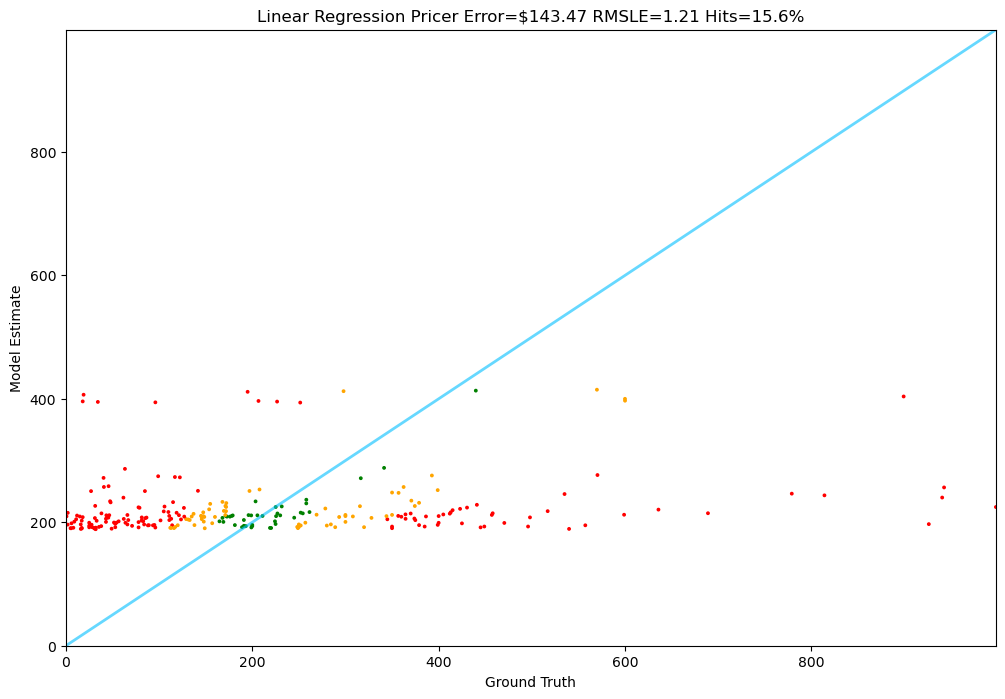

In [37]:
# test it

Tester.test(linear_regression_pricer)

In [46]:
# For the next few models, we prepare our documents and prices
# Note that we use the test prompt for the documents, otherwise we'll reveal the answer!!

prices = np.array([float(item.price) for item in train])
documents = [item.test_prompt() for item in train]

In [47]:
# Use the CountVectorizer for a Bag of Words model

np.random.seed(42)
vectorizer = CountVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(documents)
regressor = LinearRegression()
regressor.fit(X, prices)

LinearRegression()

In [48]:
def bow_lr_pricer(item):
    x = vectorizer.transform([item.test_prompt()])
    return max(regressor.predict(x)[0], 0)

1: Guess: $292.32 Truth: $374.41 Error: $82.09 SLE: 0.06 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $437.76 Truth: $225.00 Error: $212.76 SLE: 0.44 Item: Microsoft Surface 3 7G6-00001 10.8 Inch ...
3: Guess: $81.54 Truth: $61.73 Error: $19.81 SLE: 0.08 Item: Dorman 741-714 Front Passenger Side Powe...
4: Guess: $334.43 Truth: $599.99 Error: $265.56 SLE: 0.34 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $63.49 Truth: $16.97 Error: $46.52 SLE: 1.63 Item: The Best Card Company - 20 Bulk Animal N...
6: Guess: $125.56 Truth: $31.99 Error: $93.57 SLE: 1.81 Item: ITSHINY Waterproof Laptop Travel Backpac...
7: Guess: $150.39 Truth: $101.55 Error: $48.84 SLE: 0.15 Item: Uniweld MTF-9 Cap'n Hook 9 Flame Tip sil...
8: Guess: $239.00 Truth: $289.00 Error: $50.00 SLE: 0.04 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $400.34 Truth: $635.86 Error: $235.52 SLE: 0.21 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $245.03 Truth: $66.00 Error:

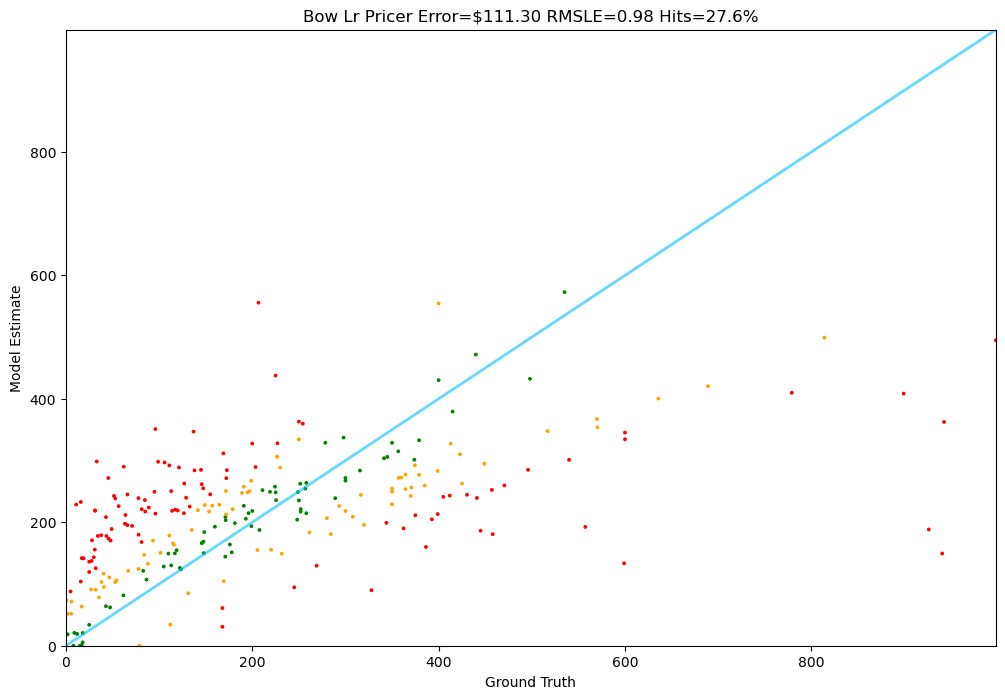

In [49]:
# test it

Tester.test(bow_lr_pricer)

In [50]:
# The amazing word2vec model, implemented in gensim NLP library

np.random.seed(42)

# Preprocess the documents
processed_docs = [simple_preprocess(doc) for doc in documents]

# Train Word2Vec model
w2v_model = Word2Vec(sentences=processed_docs, vector_size=400, window=5, min_count=1, workers=8)

In [51]:
# This step of averaging vectors across the document is a weakness in our approach

def document_vector(doc):
    doc_words = simple_preprocess(doc)
    word_vectors = [w2v_model.wv[word] for word in doc_words if word in w2v_model.wv]
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(w2v_model.vector_size)

# Create feature matrix
X_w2v = np.array([document_vector(doc) for doc in documents])

In [52]:
# Run Linear Regression on word2vec

word2vec_lr_regressor = LinearRegression()
word2vec_lr_regressor.fit(X_w2v, prices)

LinearRegression()

In [ ]:
def word2vec_lr_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, word2vec_lr_regressor.predict([doc_vector])[0])

1: Guess: $247.49 Truth: $374.41 Error: $126.92 SLE: 0.17 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $449.33 Truth: $225.00 Error: $224.33 SLE: 0.48 Item: Microsoft Surface 3 7G6-00001 10.8 Inch ...
3: Guess: $120.65 Truth: $61.73 Error: $58.92 SLE: 0.44 Item: Dorman 741-714 Front Passenger Side Powe...
4: Guess: $364.71 Truth: $599.99 Error: $235.28 SLE: 0.25 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $0.00 Truth: $16.97 Error: $16.97 SLE: 8.34 Item: The Best Card Company - 20 Bulk Animal N...
6: Guess: $87.26 Truth: $31.99 Error: $55.27 SLE: 0.97 Item: ITSHINY Waterproof Laptop Travel Backpac...
7: Guess: $103.60 Truth: $101.55 Error: $2.05 SLE: 0.00 Item: Uniweld MTF-9 Cap'n Hook 9 Flame Tip sil...
8: Guess: $244.97 Truth: $289.00 Error: $44.03 SLE: 0.03 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $343.81 Truth: $635.86 Error: $292.05 SLE: 0.38 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $182.17 Truth: $66.00 Error: 

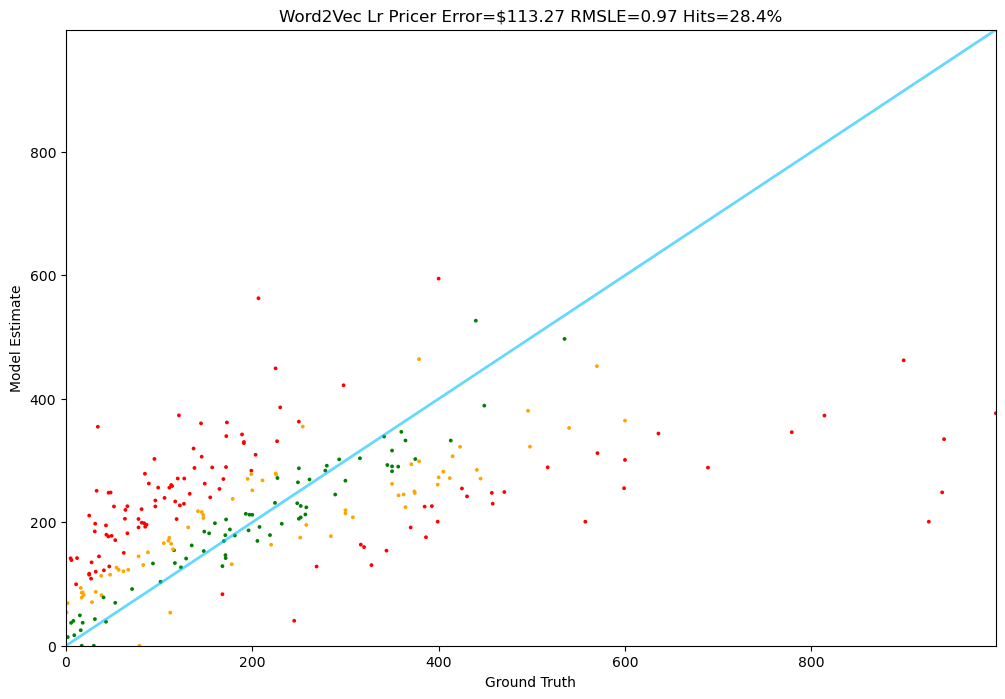

In [ ]:
Tester.test(word2vec_lr_pricer)

In [ ]:
# Support Vector Machines

np.random.seed(42)
svr_regressor = LinearSVR()

svr_regressor.fit(X_w2v, prices)

LinearSVR()

In [ ]:
def svr_pricer(item):
    np.random.seed(42)
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(float(svr_regressor.predict([doc_vector])[0]),0)

1: Guess: $242.91 Truth: $374.41 Error: $131.50 SLE: 0.19 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $441.00 Truth: $225.00 Error: $216.00 SLE: 0.45 Item: Microsoft Surface 3 7G6-00001 10.8 Inch ...
3: Guess: $97.10 Truth: $61.73 Error: $35.37 SLE: 0.20 Item: Dorman 741-714 Front Passenger Side Powe...
4: Guess: $306.29 Truth: $599.99 Error: $293.70 SLE: 0.45 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $0.00 Truth: $16.97 Error: $16.97 SLE: 8.34 Item: The Best Card Company - 20 Bulk Animal N...
6: Guess: $78.95 Truth: $31.99 Error: $46.96 SLE: 0.78 Item: ITSHINY Waterproof Laptop Travel Backpac...
7: Guess: $74.75 Truth: $101.55 Error: $26.80 SLE: 0.09 Item: Uniweld MTF-9 Cap'n Hook 9 Flame Tip sil...
8: Guess: $189.56 Truth: $289.00 Error: $99.44 SLE: 0.18 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $281.13 Truth: $635.86 Error: $354.73 SLE: 0.66 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $100.28 Truth: $66.00 Error: $

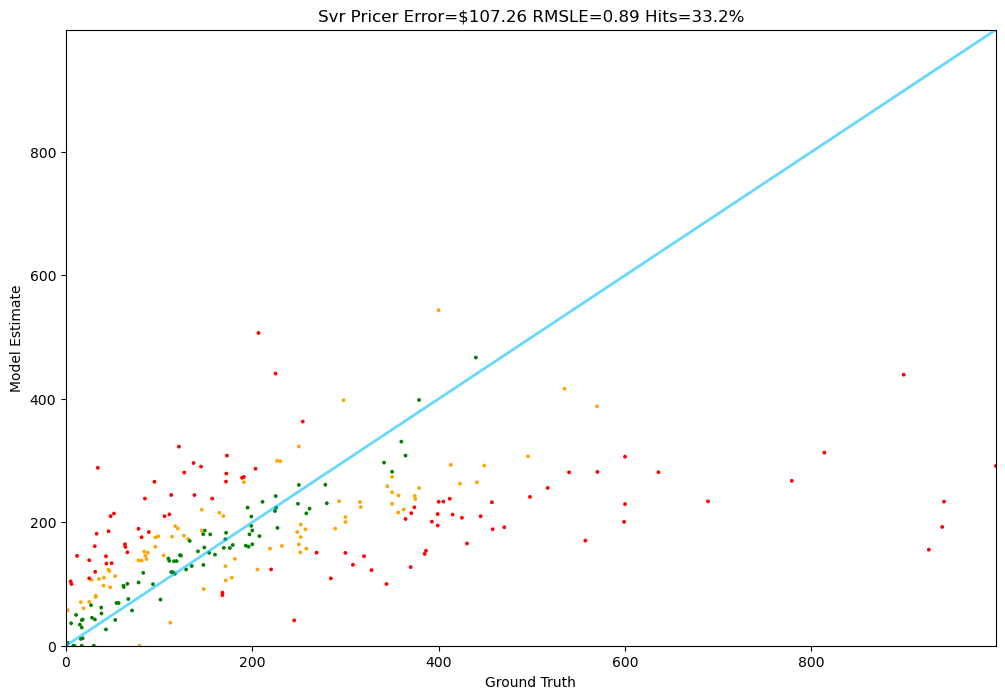

In [63]:
Tester.test(svr_pricer)

In [64]:
# And the powerful Random Forest regression

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=8)
rf_model.fit(X_w2v, prices)

# np.random.seed(42)

# # Use only 10% of training data (40,000 items instead of 400,000)
# subset_size = 40000
# indices = np.random.choice(len(prices), size=subset_size, replace=False)
# X_w2v_subset = X_w2v[indices]
# prices_subset = prices[indices]

# print(f"Training Random Forest on {subset_size:,} items instead of {len(prices):,}")
# print(f"Feature matrix size: {X_w2v_subset.shape}")

# rf_model = RandomForestRegressor(
#     n_estimators=50,     # Reduced from 100
#     random_state=42, 
#     n_jobs=4,           # Reduced from 8
#     max_depth=10,       # Limit tree depth
#     min_samples_split=20 # Prevent overfitting
# )

# rf_model.fit(X_w2v_subset, prices_subset)
# print("Random Forest training completed!")

RandomForestRegressor(n_jobs=8, random_state=42)

In [65]:
def random_forest_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, rf_model.predict([doc_vector])[0])

1: Guess: $323.62 Truth: $374.41 Error: $50.79 SLE: 0.02 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $342.25 Truth: $225.00 Error: $117.25 SLE: 0.17 Item: Microsoft Surface 3 7G6-00001 10.8 Inch ...
3: Guess: $121.99 Truth: $61.73 Error: $60.26 SLE: 0.45 Item: Dorman 741-714 Front Passenger Side Powe...
4: Guess: $404.45 Truth: $599.99 Error: $195.54 SLE: 0.15 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $17.28 Truth: $16.97 Error: $0.31 SLE: 0.00 Item: The Best Card Company - 20 Bulk Animal N...
6: Guess: $69.90 Truth: $31.99 Error: $37.91 SLE: 0.59 Item: ITSHINY Waterproof Laptop Travel Backpac...
7: Guess: $165.04 Truth: $101.55 Error: $63.49 SLE: 0.23 Item: Uniweld MTF-9 Cap'n Hook 9 Flame Tip sil...
8: Guess: $253.78 Truth: $289.00 Error: $35.22 SLE: 0.02 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $294.89 Truth: $635.86 Error: $340.97 SLE: 0.59 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $117.95 Truth: $66.00 Error: 

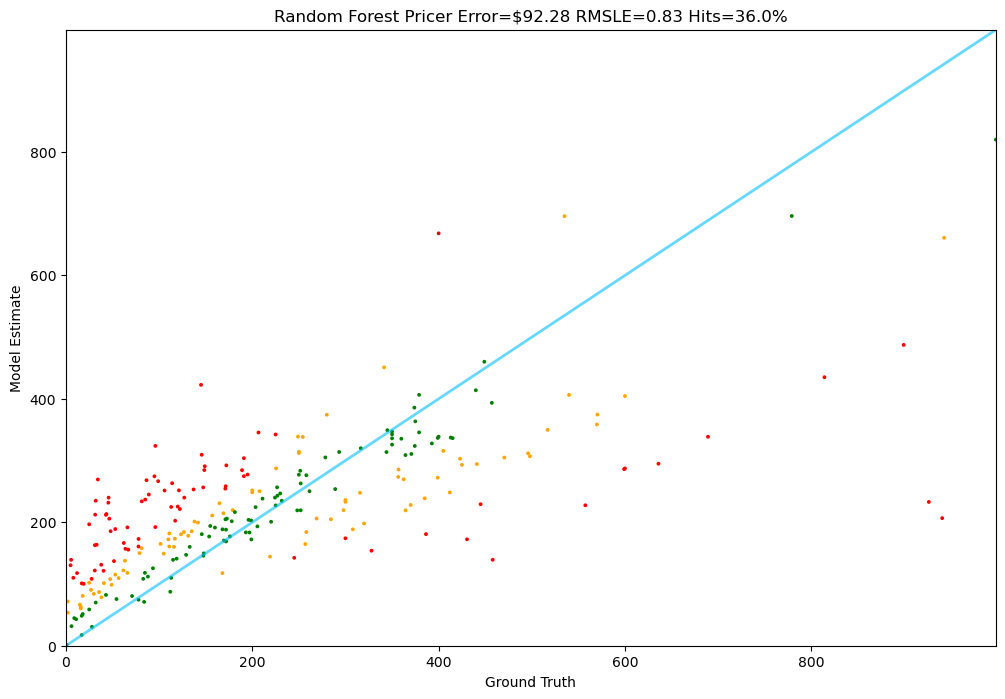

In [66]:
Tester.test(random_forest_pricer)